## **最简单的示例**

你好，张三👉


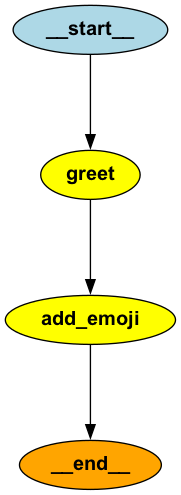

In [4]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class HelloState(TypedDict):
    name: str
    greeting: str

def greet(state: HelloState) -> dict:
    name = state["name"]

    return {"greeting": f"你好，{name}"}

def add_emoji(state: HelloState) -> dict:
    greeting = state["greeting"]  # 获取前一个节点的信息

    return {"greeting": greeting + "👉"}

# 构建图
graph = StateGraph(HelloState)
graph.add_node("greet", greet)
graph.add_node("add_emoji", add_emoji)

graph.add_edge(START, "greet")
graph.add_edge("greet", "add_emoji")
graph.add_edge("add_emoji", END)

# 编译
app = graph.compile()

# 运行
result = app.invoke({"name": "张三"})
print(result["greeting"])

# 打印图
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_png()))
except Exception as e:
    rint(f"Graphviz 渲染失败: {e}")
    print("\n使用 Mermaid 文本方式显示:")
    print(workflow_app.get_graph(xray=True).draw_mermaid())